# Split Strategy Comparison

**Objective:** Compare four train/validation/test split strategies to identify the most appropriate one for this demand forecasting problem.

The dataset covers approximately one year of daily sales (December 2010 – December 2011). The short time span makes split strategy selection non-trivial: standard approaches may introduce either data leakage or severe distribution shift between train and test sets.

The four strategies evaluated are:
1. **Random Shuffle** — rows split randomly, ignoring time order
2. **Chronological** — strict temporal split (train = past, test = future)
3. **Block-Shuffled** — consecutive blocks of 14 days shuffled before assignment
4. **TimeSeriesSplit with gap** — rolling-origin cross-validation with a purge gap

Each strategy is evaluated using the same model (Random Forest) and the same features across all 5 selected categories.

## Step 1: Setup

Evaluation, feature engineering and the block-shuffled split are imported
from the `src/` package rather than redefined here, so this notebook uses the
same implementations as every other one. The three strategies that exist only
for this comparison — random, chronological, TimeSeriesCV — are defined below.

Run from the repository root.

In [3]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit

from src import config, features as feat, splits as spl
from src.metrics import evaluate_forecast

daily = pd.read_csv(config.DAILY_CLEAN, parse_dates=["Date"])
daily = daily[~daily["Category"].isin(config.EXCLUDED_CATEGORIES)]
all_categories = sorted(daily["Category"].unique())

print("shape:", daily.shape)
print("categories:", len(all_categories))
print("range:", daily["Date"].min().date(), "to", daily["Date"].max().date())

shape: (20196, 5)
categories: 54
range: 2010-12-01 to 2011-12-09


## Step 2: Split functions

`block_shuffled_split` comes from `src.splits`. The other three are defined
here because they exist only as comparison baselines — no other notebook uses
them.

- **Random Shuffle:** rows assigned at random, ignoring time order entirely.
- **Chronological:** sorted by date, split at fixed proportions — train on the
  past, test on the future.
- **Block-Shuffled:** consecutive 14-day blocks shuffled before assignment —
  preserves local temporal structure while limiting distribution shift.
- **TimeSeriesCV with gap:** rolling-origin cross-validation with a 35-day
  purge gap between train and test in each fold — zero leakage, but small
  training sets on a one-year dataset.

In [5]:
def random_split(data, random_state=42):
    train_val, test = train_test_split(data, test_size=0.15,
                                       random_state=random_state)
    train, val = train_test_split(train_val, test_size=0.176,
                                  random_state=random_state)
    return {"train": train.reset_index(drop=True),
            "validation": val.reset_index(drop=True),
            "test": test.reset_index(drop=True)}


def chronological_split(data, train_size=0.70, val_size=0.15):
    data = data.sort_values("Date").reset_index(drop=True)
    n = len(data)
    a, b = int(n * train_size), int(n * (train_size + val_size))
    return {"train": data.iloc[:a].copy(),
            "validation": data.iloc[a:b].copy(),
            "test": data.iloc[b:].copy()}


def timeseries_cv_split(data, n_splits=5, gap=35):
    data = data.sort_values("Date").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    return [{"train": data.iloc[tr].copy(), "test": data.iloc[te].copy()}
            for tr, te in tscv.split(data)]


SPLITS = {
    "Random Shuffle": random_split,
    "Chronological": chronological_split,
    "Block-Shuffled": lambda d: spl.block_shuffled_split(d),
}
print("defined:", list(SPLITS) + ["TimeSeriesCV (gap=35)"])

defined: ['Random Shuffle', 'Chronological', 'Block-Shuffled', 'TimeSeriesCV (gap=35)']


## Step 3: Dataset preparation

`build_features` creates the target — total sales over the next X=7 days,
computed Y=7 days in advance — plus lags, rolling statistics, calendar and
holiday features.

All rolling features are shifted by one day before the window is applied, so
today's quantity never enters a feature describing today.

In [7]:
X_horizon, Y_lead = 7, 7
target_col = config.target_name(X_horizon, Y_lead)

datasets = {}
for cat in all_categories:
    d = feat.build_features(daily, cat, X=X_horizon, Y=Y_lead)
    if len(d) >= 50:
        datasets[cat] = d

features = feat.available_features(next(iter(datasets.values())))
print(f"{len(datasets)} categories prepared, {len(features)} features")
print(f"target: {target_col}")

54 categories prepared, 30 features
target: target_X7_Y7


## Step 5: Split Comparison — Fixed Model (Random Forest)

To select the best split strategy, we use Random Forest as a fixed
reference model across all 54 categories and all 4 splits.

The goal is to find which split gives the most reliable and generalizable
results — independently of the model choice.

Three criteria are used:
- **Average Test WAPE** — lower is better
- **Median Test WAPE** — more robust to outliers
- **Positive R² count** — how many categories have R² > 0
- **Leakage risk** — percentage of contaminated test rows

In [9]:
rf_model = RandomForestRegressor(n_estimators=200,
                                 random_state=config.RANDOM_STATE, n_jobs=-1)
rows = []

for split_name, split_fn in SPLITS.items():
    print(f"  -> {split_name}")
    for cat, data in datasets.items():
        s = split_fn(data)
        train, val, test = s["train"], s["validation"], s["test"]
        train_val = pd.concat([train, val], ignore_index=True)

        m1 = clone(rf_model).fit(train[features], train[target_col])
        m2 = clone(rf_model).fit(train_val[features], train_val[target_col])

        tr = evaluate_forecast(train[target_col], m1.predict(train[features]))
        va = evaluate_forecast(val[target_col], m1.predict(val[features]))
        te = evaluate_forecast(test[target_col], m2.predict(test[features]))

        rows.append({"Split": split_name, "Category": cat,
                     "Train WAPE (%)": round(tr["wape"], 2),
                     "Val WAPE (%)": round(va["wape"], 2),
                     "Test WAPE (%)": round(te["wape"], 2),
                     "Test R2": round(te["r2"], 3)})

print("done")

  -> Random Shuffle
  -> Chronological
  -> Block-Shuffled
done


In [10]:
print("  -> TimeSeriesCV (gap=35)")

for cat, data in datasets.items():
    tw, tew, r2s = [], [], []
    for fold in timeseries_cv_split(data):
        tr_f, te_f = fold["train"], fold["test"]
        if len(tr_f) < 10 or len(te_f) < 5:
            continue
        m = clone(rf_model).fit(tr_f[features], tr_f[target_col])
        a = evaluate_forecast(tr_f[target_col], m.predict(tr_f[features]))
        b = evaluate_forecast(te_f[target_col], m.predict(te_f[features]))
        tw.append(a["wape"]); tew.append(b["wape"]); r2s.append(b["r2"])

    rows.append({"Split": "TimeSeriesCV (gap=35)", "Category": cat,
                 "Train WAPE (%)": round(np.mean(tw), 2) if tw else np.nan,
                 "Val WAPE (%)": np.nan,
                 "Test WAPE (%)": round(np.mean(tew), 2) if tew else np.nan,
                 "Test R2": round(np.mean(r2s), 3) if r2s else np.nan})

split_comparison_df = pd.DataFrame(rows)
split_comparison_df.to_csv(config.RESULTS / "split_comparison_raw.csv", index=False)
print("done")

  -> TimeSeriesCV (gap=35)
done


In [11]:
summary = (
    split_comparison_df.groupby("Split")
    .agg(Avg_Test_WAPE=("Test WAPE (%)", "mean"),
         Median_Test_WAPE=("Test WAPE (%)", "median"),
         Avg_Test_R2=("Test R2", "mean"),
         Positive_R2=("Test R2", lambda x: (x > 0).sum()),
         Total=("Test R2", "count"))
    .round(2).reset_index()
)
summary["Positive R2"] = (summary["Positive_R2"].astype(str) + "/"
                          + summary["Total"].astype(str))
summary = summary.drop(columns=["Positive_R2", "Total"])
summary

,Split,Avg_Test_WAPE,Median_Test_WAPE,Avg_Test_R2,Positive R2
0,Block-Shuffled,35.95,33.34,-0.07,36/54
1,Chronological,45.66,33.73,-2.32,2/54
2,Random Shuffle,20.58,17.60,0.73,54/54
3,TimeSeriesCV (gap=35),64.51,46.00,-4.80,0/54


## Step 6: Visualization of Split Comparison

Two plots are shown:
- **Test WAPE distribution** — boxplot per split across all 54 categories
- **Test R²** — count of positive R² per split

C:\Users\user\AppData\Local\Temp\ipykernel_42104\1611418046.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=15, ha="right")


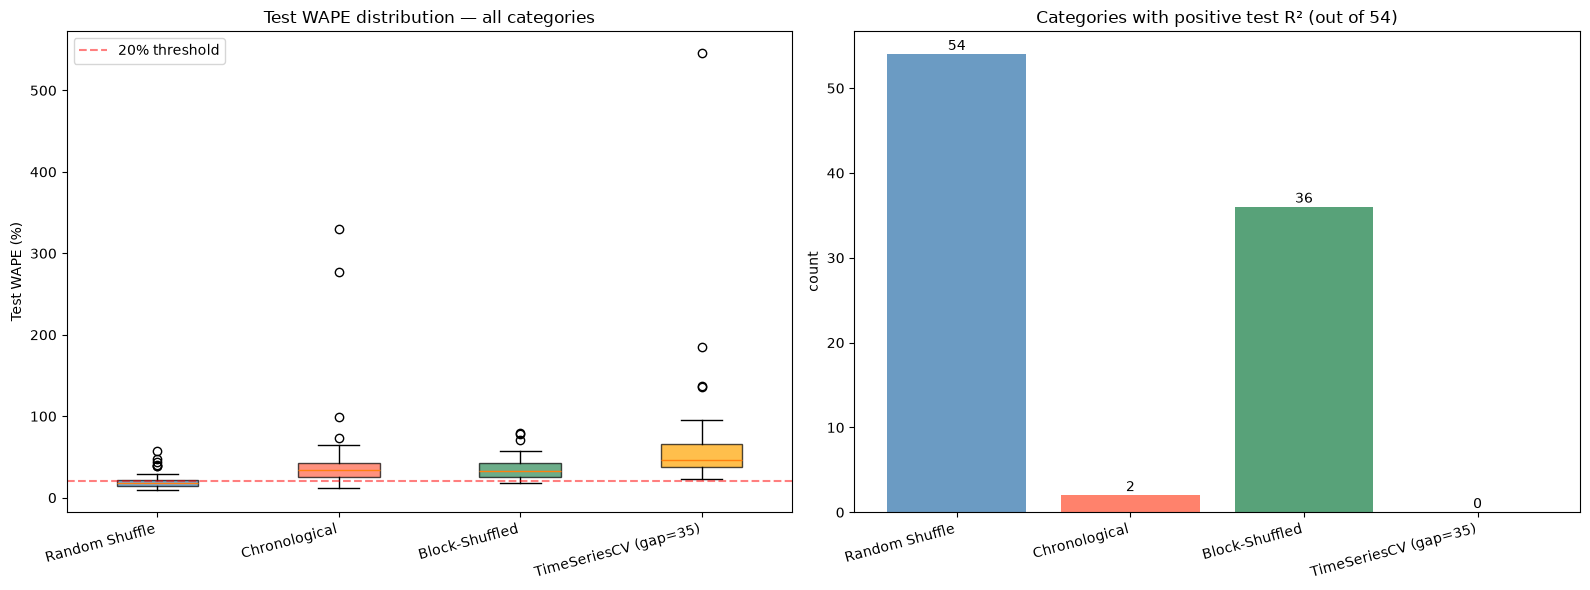

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = ["Random Shuffle", "Chronological", "Block-Shuffled",
         "TimeSeriesCV (gap=35)"]
colors = ["steelblue", "tomato", "seagreen", "orange"]

ax = axes[0]
bp = ax.boxplot([split_comparison_df[split_comparison_df["Split"] == s]
                 ["Test WAPE (%)"].dropna().values for s in order],
                patch_artist=True, tick_labels=order)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(20, color="red", ls="--", alpha=0.5, label="20% threshold")
ax.set_title("Test WAPE distribution — all categories")
ax.set_ylabel("Test WAPE (%)")
ax.set_xticklabels(order, rotation=15, ha="right")
ax.legend()

ax = axes[1]
pos = [(split_comparison_df[split_comparison_df["Split"] == s]["Test R2"] > 0).sum()
       for s in order]
bars = ax.bar(order, pos, color=colors, alpha=0.8)
for b, v in zip(bars, pos):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, str(v), ha="center")
ax.set_title(f"Categories with positive test R² (out of {len(datasets)})")
ax.set_ylabel("count")
ax.set_xticklabels(order, rotation=15, ha="right")

plt.tight_layout()
plt.show()

## Step 7: Leakage Risk Analysis

Beyond predictive performance, we quantify the leakage risk for each split.

Two rows share a leakage risk if their temporal distance is less than 
X-1 = 6 days, meaning their target windows overlap.

> Note: This measures target window overlap only. Feature-level leakage 
> (lag/rolling features sharing past values) is inherent to time series 
> modeling and is not counted here.

The leakage risk quantified here refers to target window overlap —
two rows whose prediction windows cover the same future days.
Feature-level leakage (lag/rolling features sharing past values)
is inherent to time series modeling and is not counted here.

In [20]:
leakage = []
data_ref = datasets[all_categories[0]]

for split_name, split_fn in SPLITS.items():
    s = split_fn(data_ref)
    leakage.append({"Split": split_name,
                    "Test rows": len(s["test"]),
                    "Leakage (%)": round(spl.leakage_ratio(s, X_horizon) * 100, 1)})

leakage.append({"Split": "TimeSeriesCV (gap=35)", "Test rows": "-",
                "Leakage (%)": 0.0})

pd.DataFrame(leakage)

,Split,Test rows,Leakage (%)
0,Random Shuffle,50,100.0
1,Chronological,50,0.0
2,Block-Shuffled,70,60.0
3,TimeSeriesCV (gap=35),-,0.0


## Step 8: Decision

| Split | Avg Test WAPE | Median | Avg Test R² | Positive R² | Leakage | Verdict |
|---|---|---|---|---|---|---|
| Random Shuffle | 20.58 | 17.60 | 0.73 | 54/54 | 100% | Rejected — leakage |
| Chronological | 45.66 | 33.73 | −2.32 | 2/54 | 0% | Rejected — distribution shift |
| **Block-Shuffled** | **35.95** | **33.34** | **−0.07** | **36/54** | 60% | **Selected** |
| TimeSeriesCV (gap=35) | 64.51 | 46.00 | −4.80 | 0/54 | 0% | Rejected — too little data per fold |

Block-shuffled is selected. No split is clean on a one-year dataset:

- **Random Shuffle** gives by far the best metrics — and that is the problem.
  100% of test rows have a training neighbour whose target window overlaps
  their own, so the score measures memorisation rather than forecasting.
  54/54 positive R² is a symptom, not an achievement.
- **Chronological** is leakage-free but fails unevenly. Its median (33.73) is
  essentially the same as block-shuffled, while its mean (45.66) is ten points
  worse and its average R² is −2.32. The boxplot shows why: a few categories
  reach 275–330% WAPE. Those are the seasonal ones, where the test period
  falls on a season the model has never seen. One year provides no second
  example of Christmas.
- **TimeSeriesCV** is clean and unusable: 0/54 positive R², with outliers
  above 500%. With ~330 usable rows per category, five folds leave training
  sets too small to learn from.
- **Block-Shuffled** produces exploitable metrics with a bounded, measured
  leakage risk — and, visible in the boxplot, by far the tightest distribution
  of the four. It does not merely win on average; it produces the fewest
  extreme failures.

### Limitation

60% of test rows have a training neighbour within X−1 = 6 days, meaning their
target windows overlap. All results in this project are therefore optimistic
relative to true deployment performance. This measures target-window overlap
only; feature-level leakage, where lag and rolling features share past values,
is inherent to time series modelling and is not counted.

Purged cross-validation with an embargo period would remove this properly and
is the natural next step. With several years of data, chronological or
TimeSeriesCV would become viable and preferable.

## Step 9: The selected split is still unstable

Choosing block-shuffled was necessary but not sufficient. Every result above
comes from a single draw of the blocks, and re-drawing them changes the answer
substantially.

Re-running Random Forest across 30 seeds on the five representative
categories, comparing the plain block split against a stratified one:

| Category | WAPE sd, original | WAPE sd, stratified | Worst case | Denominator CV |
|---|---|---|---|---|
| Tealight Holders & Sets | 8.2 | 6.2 | 45.2 → 33.6 | 0.181 → 0.066 |
| Cake Cases & Baking | 9.7 | **3.9** | 50.8 → 39.3 | 0.147 → 0.053 |
| Jumbo Bags & Shoppers | 11.0 | **4.6** | 72.9 → 44.7 | 0.235 → 0.053 |
| Christmas Decorations | 42.8 | **8.8** | 209.0 → 55.3 | 0.747 → 0.107 |
| Jewellery - Earrings | 53.5 | **4.6** | 360.0 → 84.3 | 0.600 → 0.090 |

**The cause is seasonal imbalance between splits.** With roughly 24 blocks,
some draws place the entire Christmas ramp in one split and none of it in
another. Because WAPE divides by the sum of actuals in the evaluation set, a
validation set containing the peak has a large denominator and therefore a
small WAPE almost regardless of forecast quality.

This was measured directly: across 30 seeds, WAPE correlates **−0.587** with
the evaluation set's denominator while MAE correlates **+0.863**. The two
metrics disagree on identical predictions, which is the signature of a
denominator artefact rather than a modelling effect.

`stratified_block_split` orders the 14-day blocks by mean demand and deals
them out so that each split receives a proportional share of high- and
low-season weeks. The last column shows the effect: variation in the
evaluation denominator across seeds falls from 0.747 to 0.107 on Christmas
Decorations, and from 0.600 to 0.090 on Jewellery. The evaluation sets become
comparable to one another, which is what makes their WAPE values comparable.

Note that the mean WAPE *rises* for Cake Cases, from 29.9 to 32.6. This is not
a degradation — it is the disappearance of favourable draws that were pulling
the average down. Stratification produces a fairer number, not a flattering
one.

Note also that stratification reduces the **variance** of the estimate, not
the difficulty of the problem. One year of data still contains exactly one
Christmas, and no split strategy creates seasonal signal that is not there.

Full analysis in `RESULTS_REVISED.md`; raw figures in
`results/split_strategy_comparison.csv`.

In [24]:
strat = pd.read_csv(config.RESULTS / "split_strategy_comparison.csv")
strat

,Category,split,wape_mean,wape_std,wape_max,denom_cv
0,Tealight Holders & Sets,original,24.3,8.2,45.2,0.181
1,Tealight Holders & Sets,stratified,22.3,6.2,33.6,0.066
2,Cake Cases & Baking Accessories,original,29.9,9.7,50.8,0.147
3,Cake Cases & Baking Accessories,stratified,32.6,3.9,39.3,0.053
4,Jumbo Bags & Shoppers,original,39.4,11.0,72.9,0.235
5,Jumbo Bags & Shoppers,stratified,33.1,4.6,44.7,0.053
6,Christmas Decorations,original,46.5,42.8,209.0,0.747
7,Christmas Decorations,stratified,29.5,8.8,55.3,0.107
8,Jewellery - Earrings,original,96.4,53.5,360.0,0.600
9,Jewellery - Earrings,stratified,77.2,4.6,84.3,0.090
